
# POD on Masked Structured Grids — Hands‑On Tutorial

**Goal.** Teach you how to compute Proper Orthogonal Decomposition (POD) for 2‑D structured grids with padding, stacked over time into a 3‑D array `(time, H, W)`. This notebook walks through:
1) a 5‑minute intro to POD,  
2) generating a small synthetic dataset on a masked 15×15 grid, and  
3) implementing POD (via SVD) to extract spatial modes, temporal coefficients, energy spectra, and reconstructions.

> Works with NumPy/Matplotlib only; no extra dependencies required.



## 0) What is POD (in practice)?

- You have `T` snapshots of a field on a grid. Only some grid cells are *physical* (others are padding). Create a **mask** to pick the valid cells.
- Flatten those valid cells per snapshot → a 2‑D matrix `X ∈ R^{M×T}` where `M` is the number of valid points.
- Subtract the temporal mean at each spatial point: `Xc = X − mean(X, axis=1)`.
- Compute the thin SVD: `Xc = U Σ Vᵀ`.
  - **Spatial modes** (a.k.a. POD modes): columns of `U` (size `M×r`).
  - **Temporal coefficients** (a.k.a. modal amplitudes): rows of `Σ Vᵀ` (size `r×T`).
  - **Energy** captured by mode `i`: `Σᵢ² / Σⱼ²`.
- Rank‑`r` reconstruction: `X̂ᵣ = U[:, :r] Σ[:r, :r] V[:r, :] + mean`.

POD gives the most energetic orthogonal basis for your dataset under the L2 inner product. In flows, the leading modes often correspond to coherent structures.



## 1) Setup


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Use default matplotlib settings; do not set custom colors or styles (teaching constraint)
np.set_printoptions(suppress=True, precision=4)

# Load the same mask used in your project
mask = np.array([
[0,0,0,0,1,1,1,1,1,1,1,0,0,0,0],
[0,0,1,1,1,1,1,1,1,1,1,1,1,0,0],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[0,0,1,1,1,1,1,1,1,1,1,1,1,0,0],
[0,0,0,0,1,1,1,1,1,1,1,0,0,0,0],
], dtype=np.uint8)

H, W = mask.shape
M = int(mask.sum())  # number of valid points
print(f"Grid: {H}x{W}, valid points (M) = {M}")
print(mask)

Grid: 15x15, valid points (M) = 193
[[0 0 0 0 1 1 1 1 1 1 1 0 0 0 0]
 [0 0 1 1 1 1 1 1 1 1 1 1 1 0 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [0 0 1 1 1 1 1 1 1 1 1 1 1 0 0]
 [0 0 0 0 1 1 1 1 1 1 1 0 0 0 0]]



## 2) Generate a synthetic dataset (or load yours)

Below we create a rank‑3 flow evolving in time, add light noise, and enforce the mask. This mimics mass‑flow maps on the same 15×15 footprint.


In [6]:
rng = np.random.default_rng(42)
T = 200  # number of time snapshots

yy, xx = np.mgrid[0:H, 0:W]
x = (xx - (W-1)/2)/((W-1)/2)
y = (yy - (H-1)/2)/((H-1)/2)

# Spatial modes
mode1 = np.exp(-2.5*(x**2 + y**2))
mode2 = x
theta = np.arctan2(y, x)
mode3 = np.sin(3*theta) * np.exp(-1.5*(x**2 + y**2))

for m in (mode1, mode2, mode3):
    m[mask == 0] = 0.0

def norm_masked(arr, mask):
    v = arr[mask.astype(bool)]
    n = np.linalg.norm(v) + 1e-12
    return arr / n

mode1 = norm_masked(mode1, mask)
mode2 = norm_masked(mode2, mask)
mode3 = norm_masked(mode3, mask)

t = np.linspace(0, 10, T)
a1 = 2.0 + 1.5*np.sin(2*np.pi*0.5*t)
a2 = 0.8*np.cos(2*np.pi*0.12*t + 0.7)
a3 = 0.6*np.sin(2*np.pi*0.22*t)

data_stack = np.zeros((T, H, W), dtype=float)
for k in range(T):
    field = a1[k]*mode1 + a2[k]*mode2 + a3[k]*mode3
    noise = 0.05 * rng.standard_normal((H, W))
    field = field + noise * mask
    data_stack[k] = field * mask

print("Synthetic data_stack shape:", data_stack.shape)

Synthetic data_stack shape: (200, 15, 15)



## 3) Build the data matrix `X` from the masked grid

We flatten valid cells only. `X` has shape `(M, T)`.


In [7]:
valid_idx = mask.astype(bool)

def stack_to_X(stack, valid_idx):
    # stack: (T, H, W) → X: (M, T)
    T_, H_, W_ = stack.shape
    assert H_ == H and W_ == W
    X = np.zeros((valid_idx.sum(), T_), dtype=float)
    for k in range(T_):
        X[:, k] = stack[k][valid_idx]
    return X

X = stack_to_X(data_stack, valid_idx)
print("X shape (M,T):", X.shape)

X shape (M,T): (193, 200)



## 4) POD via SVD

We subtract the temporal mean at each spatial point, compute the thin SVD, then extract:
- spatial modes `Phi = U` (size `M×r`),
- temporal coefficients `A = Σ Vᵀ` (size `r×T`),
- mode energies from `Σ²`.


In [8]:
def pod_svd(X):
    # Center by removing mean across time for each spatial point
    mean = X.mean(axis=1, keepdims=True)
    Xc = X - mean

    # Thin SVD
    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)  # Xc = U @ np.diag(s) @ Vt

    # Temporal coefficients
    A = (s[:, None] * Vt)  # r x T

    # Energy (variance) captured
    energy = (s**2) / np.sum(s**2)

    return U, s, Vt, A, energy, mean

U, s, Vt, A, energy, mean = pod_svd(X)
r = 8  # number of modes to inspect
print("Singular values (first 8):", s[:8])
print("Energy (first 8):", energy[:8])
print("Total energy:", energy.sum())

Singular values (first 8): [14.9471  7.6342  5.9242  1.3631  1.3421  1.3272  1.3169  1.2971]
Energy (first 8): [0.5441 0.1419 0.0855 0.0045 0.0044 0.0043 0.0042 0.0041]
Total energy: 1.0000000000000002



## 5) Quick diagnostics: spectrum and cumulative energy


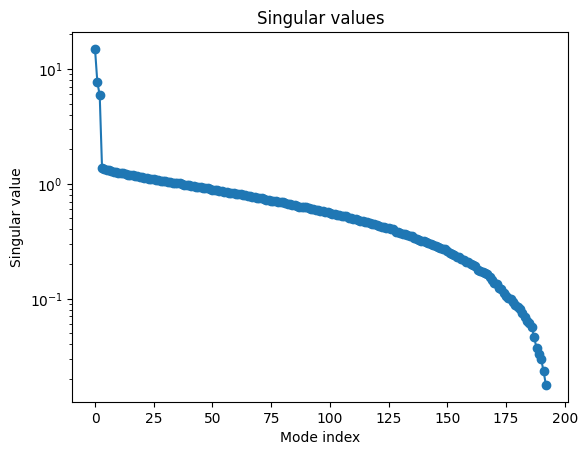

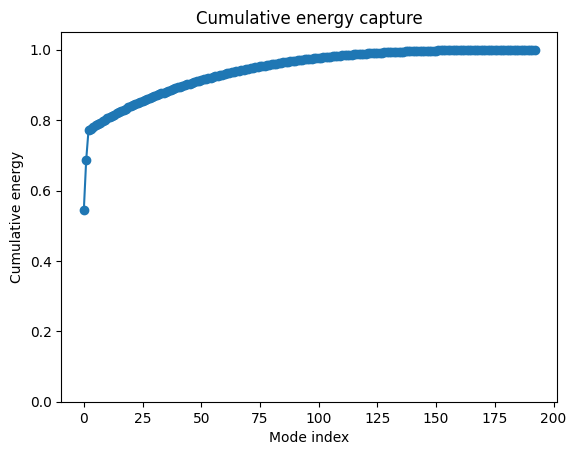

In [9]:
plt.figure()
plt.semilogy(s, marker='o')
plt.xlabel("Mode index")
plt.ylabel("Singular value")
plt.title("Singular values")
plt.show()

plt.figure()
plt.plot(np.cumsum(energy), marker='o')
plt.xlabel("Mode index")
plt.ylabel("Cumulative energy")
plt.title("Cumulative energy capture")
plt.ylim(0, 1.05)
plt.show()


## 6) Visualize leading spatial modes on the 2‑D grid


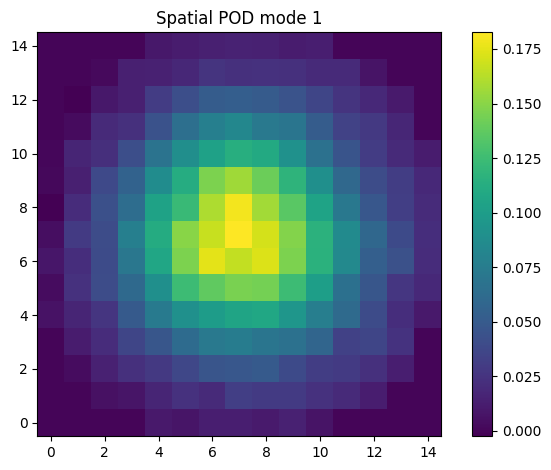

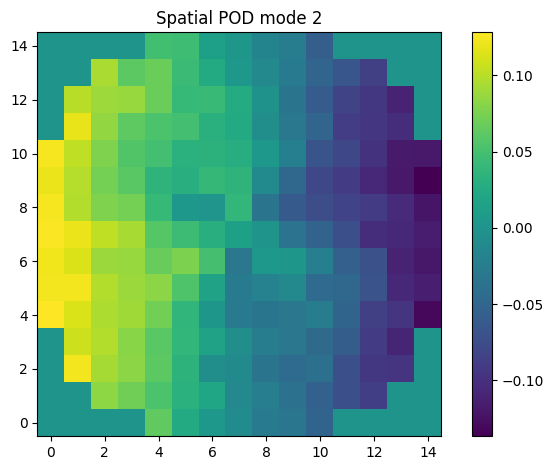

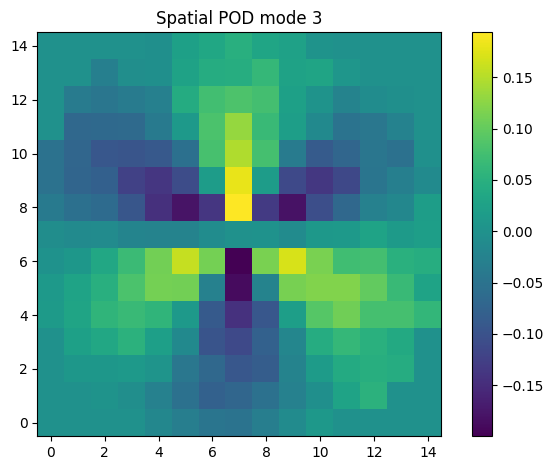

In [10]:
def unmask(vec, valid_idx, H, W):
    img = np.zeros((H, W), dtype=float)
    img[valid_idx] = vec
    return img

num_show = 3
for i in range(num_show):
    mode_img = unmask(U[:, i], valid_idx, H, W)
    plt.figure()
    plt.imshow(mode_img, origin='lower')
    plt.colorbar()
    plt.title(f"Spatial POD mode {i+1}")
    plt.tight_layout()
    plt.show()


## 7) Visualize temporal coefficients for the same modes


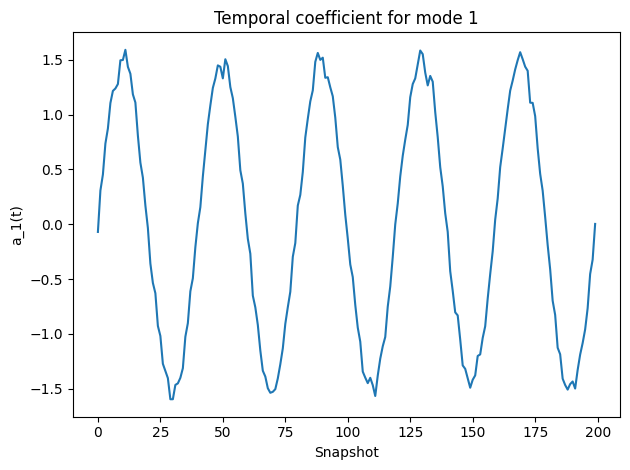

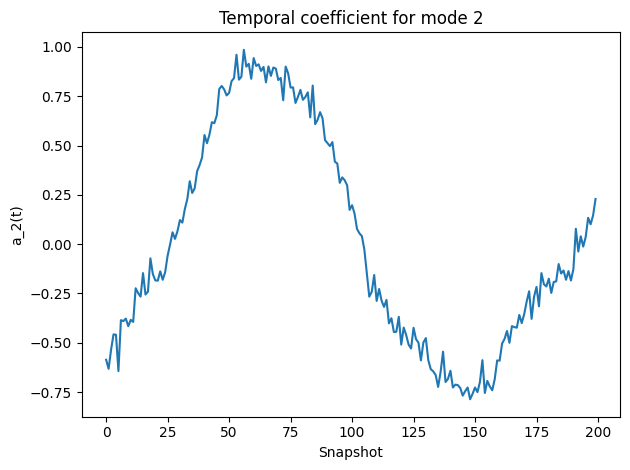

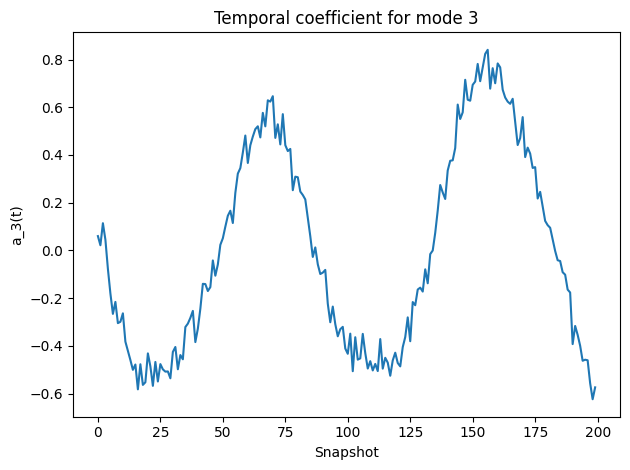

In [11]:
for i in range(num_show):
    plt.figure()
    plt.plot(A[i, :])
    plt.xlabel("Snapshot")
    plt.ylabel(f"a_{i+1}(t)")
    plt.title(f"Temporal coefficient for mode {i+1}")
    plt.tight_layout()
    plt.show()


## 8) Reconstruction demo + error

We reconstruct one snapshot using the first `r` modes and compare to the original.


Snapshot 50: MSE using r=3 modes = 0.0025145094433493775


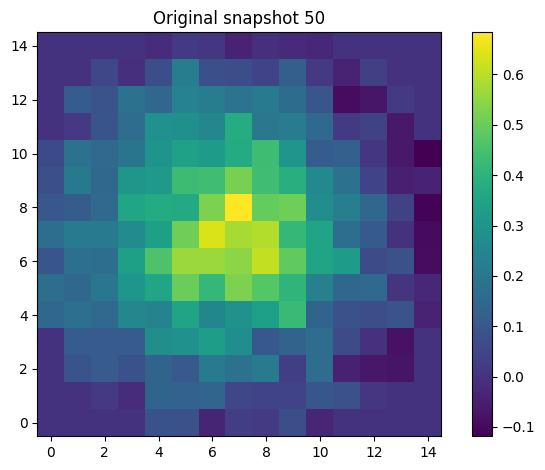

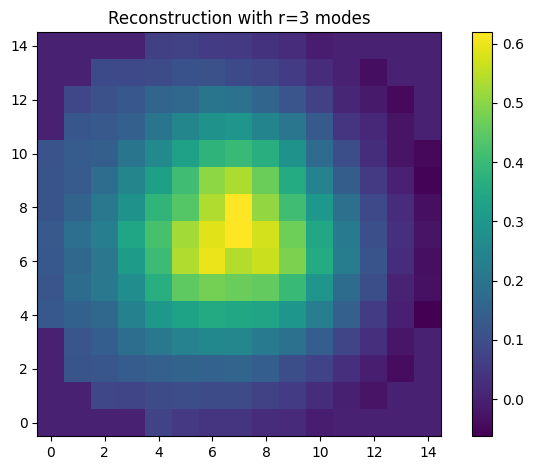

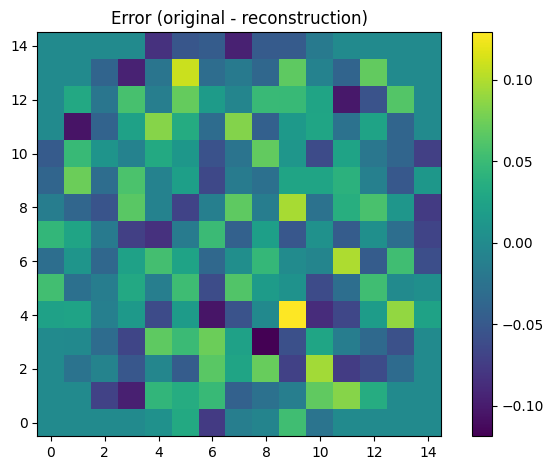

In [12]:
def reconstruct_rank_r(U, s, Vt, mean, r):
    # Xc ≈ U_r @ diag(s_r) @ Vt_r
    Xc_r = (U[:, :r] * s[:r]) @ Vt[:r, :]
    return Xc_r + mean

r_try = 3
Xhat = reconstruct_rank_r(U, s, Vt, mean, r_try)

k = 50  # pick a snapshot to compare
orig = unmask(X[:, k], valid_idx, H, W)
reco = unmask(Xhat[:, k], valid_idx, H, W)

mse = np.mean((X[:, k] - Xhat[:, k])**2)
print(f"Snapshot {k}: MSE using r={r_try} modes =", mse)

plt.figure()
plt.imshow(orig, origin='lower')
plt.colorbar()
plt.title(f"Original snapshot {k}")
plt.tight_layout()
plt.show()

plt.figure()
plt.imshow(reco, origin='lower')
plt.colorbar()
plt.title(f"Reconstruction with r={r_try} modes")
plt.tight_layout()
plt.show()

plt.figure()
plt.imshow(orig - reco, origin='lower')
plt.colorbar()
plt.title("Error (original - reconstruction)")
plt.tight_layout()
plt.show()


## 9) Notes for real data

- **Input shape.** If your real data come as `(T, H, W)` with padding, reuse the same mask and `stack_to_X`/`unmask` helpers.
- **Centering choice.** The default removes the temporal mean at each spatial point (common for POD). For stationary flows, this isolates fluctuations.
- **NaNs / non-finite values.** Replace or mask them before SVD (e.g., set to 0 within the valid mask after mean-subtraction).
- **Large problems.** For very large `T` or `M`, consider a **method of snapshots** SVD (on `T×T`) or **randomized SVD** (`sklearn.utils.extmath.randomized_svd`) for speed.
- **Scaling.** If you mix variables with different units/magnitudes, scale them appropriately before POD.
